In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Create a Curve Interpolation

## 1. Plot the data points 📌

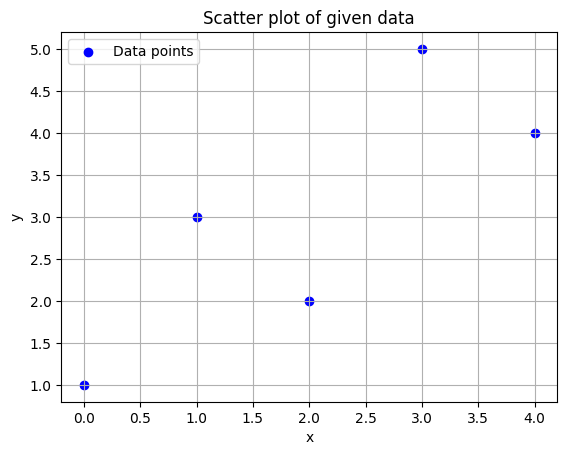

In [3]:
# Data points
x = np.array([0, 1, 2, 3, 4])
y = np.array([1, 3, 2, 5, 4])
# x = np.array([0, 5, 10, 15])
# y = np.array([1.792, 1.519, 1.308, 1.140])

# Scatter plot
plt.scatter(x, y, color='blue', marker='o', label='Data points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of given data')
plt.legend()
plt.grid(True)
plt.show()

## 2. Interpolation Methods Function

### a. Lagrange Interpolation

In [4]:
def lagrange_interpolation(x_points, y_points, x_val):
    n = len(x_points)
    result = 0
    for i in range(n):
        term = y_points[i]
        for j in range(n):
            if j != i:
                term *= (x_val - x_points[j]) / (x_points[i] - x_points[j])
        result += term
    return result

### b. Newton Interpolation
Newton’s method uses divided differences.

In [5]:
def divided_diff(x_points, y_points):
    n = len(x_points)
    coef = np.zeros([n, n])
    coef[:,0] = y_points
    for j in range(1, n):
        for i in range(n-j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x_points[i+j] - x_points[i])
    return coef[0,:]

def newton_interpolation(x_points, y_points, x_val):
    coef = divided_diff(x_points, y_points)
    n = len(x_points)
    result = coef[0]
    product = 1.0
    for i in range(1, n):
        product *= (x_val - x_points[i-1])
        result += coef[i] * product
    return result

## 3. Run the program
Define the x you want to interpolate (example is x = 3.5)

In [10]:
# Example: interpolate at x = 1.5
x_test = 3.5
y_lagrange = lagrange_interpolation(x, y, x_test)
y_newton = newton_interpolation(x, y, x_test)

print(f"Lagrange interpolation at x={x_test}: y={y_lagrange}")
print(f"Newton interpolation at x={x_test}: y={y_newton}")

Lagrange interpolation at x=3.5: y=6.085937500000001
Newton interpolation at x=3.5: y=6.085937500000002


## 4. Plot All Methods Line
_Lagrange and Newton_

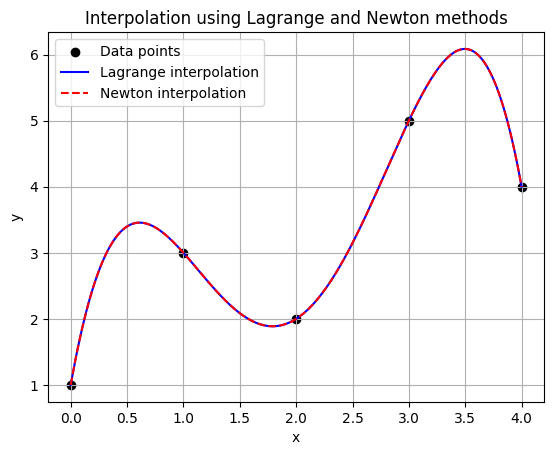

In [14]:
# Smooth curve for plotting
x_curve = np.linspace(min(x), max(x), 200)
# Plot all available x on range 200
y_lagrange_curve = [lagrange_interpolation(x, y, xi) for xi in x_curve]
y_newton_curve   = [newton_interpolation(x, y, xi) for xi in x_curve]

plt.scatter(x, y, color='black', label='Data points')
plt.plot(x_curve, y_lagrange_curve, color='blue', label='Lagrange interpolation')
plt.plot(x_curve, y_newton_curve, color='red', linestyle='--', label='Newton interpolation')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolation using Lagrange and Newton methods')
plt.legend()
plt.grid(True)
plt.show()